# Contents
1. Basics of general measurements
   - Descriptions as collections of matrices
   - Descriptions as channels
   - Partial measurements
2. Naimark's Theorem
   - Statement and proof
   - Nondestructive measurement
3. State discrimination and tomography

# Descriptions of measurements
- measurements represent an interface between quantum and classical information:
  - performing a measurement on a system extracts classical information about its quantum state.
  - in general, the system is changed (or destroyed) in the process

Initially our focus will be on **destructive measurements** -- which produce a classical outcome alone. (the post-measurement *quantum* state of the system is not specified)

**Non-destructive measurements** will be discussed in the latter part. (They can always be described as compositions of destructive measurements and channels.)

## Two ways to describe destructive measurements
1. As **collections of matrices**, one for each measurement outcome
2. As **channels** whose outputs are always classical states (represented by diagonal density matrices)

## Measurements as matrices
Throughout the discussion we suppose $XR$ is a system to be measured. For simiplicity assume the following:
- The classical state set of $X$ is $\{0,\dots, n-1\}$ (for some positive integer $n$)
- The set of measurement outcomes is $\{0,\dots, m-1\}$ (for some positive integer $m$)

Note: there are NO relationship between $n$ and $m$. Both are arbitrary positive integers.

### Reflection: Projective measurements

A *projective measurement* is described by a collection of projection matrices $\{\Pi_0, \dots, \Pi_{m-1}\}$ satisfying this condition:

$$ \Pi_0 + \dots + \Pi_{m-1} = I_X $$

**Note: The rows and columns are corresponding to the classical states of $X$. In other words, all the projection matrices $\Pi_i$ is an $n\times n$ matrix.**

If the state of $X$ is $\ket{\psi}$, each outcome $a$ appears with this probability:

$$ ||\Pi_a\ket{\psi} ||^2 $$

And this is equal to the inner product of that vector to itself so we get the expression: 

$$ ||\Pi_a\ket{\psi} ||^2 = \bra{\psi}\Pi_a\Pi_a\ket{\psi} $$

Note that **$\Pi_a$ is a projection**, so multiplying to itself doesn't do anything (*Hermitian*). So we get, 

$$ ||\Pi_a\ket{\psi} ||^2 = \bra{\psi}\Pi_a\ket{\psi} $$

We can also rewrite the expression we've obtained in a slightly different way using the **cyclic property of the trace.** That is,

$$ \text{Tr}(ABC) = \text{Tr}(BCA) = \text{Tr}(CAB) $$ 

***NOT COMMUTATIVE BUT CYCLIC***. The $\bra{\psi}$ and $\ket{\psi}$ can form a matrix if cycled. We get the expression

$$ ||\Pi_a\ket{\psi} ||^2 = \bra{\psi}\Pi_a\ket{\psi} = \text{Tr}(\Pi_a \ket{\psi}\bra{\psi})$$

**We want to write the expression like this because we want to understand how projective measurements work for density matrices.** By linearity in particular, if the state of $X$ is $\rho$, each outcome $a$ appears with this probability: 

$$ \text{Tr}(\Pi_a \rho) $$

That has to be the case because we can *always* think about a density matrices **as weighted average of pure states.**

NOTE: The point of doing this is to establish a point of reference to what we've already learned (about density matrices) and to see that this description of projective measurements is in fact a *special case* of a **more general description of measurements** that we're about to see.

### General measurements
A *general measurement* is described by a ***collection of positive semidefinite matrices $\{P_0, \dots, P_{m-1}\}$*** satisfying the condition:

$$ P_0 + \dots + P_{m-1} = I_X $$

If the state of $X$ is $\rho$, each outcome $a$ appears with this probability:

$$ \text{Tr}(P_a\rho) $$

So this is a more relaxed condition for measurements. The matrices dont need to be projection matrices they **just need to be positive semi-definite**. Note that, all projection matrices are positive semi-definite matrices. In fact, **projection matrices can be defined as positive semi-definite matrices whose eigenvalues can only be 0 and 1.**

We necessarily obtain a probability vector ( $\text{Tr}(P_0 \rho), \dots, \text{Tr}(P_{m-1}\rho)$ ) in the following way:

- These are nonnegative real numbers: $Q, R \geq 0 \Rightarrow\text{Tr}(QR)\geq 0$
  - Note that both $P_a$ and $\rho$ are positive semi-definite.
  - The trace of the product of two positive semi-definite (in this case $P_a$ and $\rho$ is always nonnegative real numbers.

- These numbers sum to 1 because:
  - $\text{Tr}(P_0\rho)+\dots + \text{Tr}(P_{m-1}\rho) = \text{Tr}((P_0 + \dots + P_{m-1})\rho) = \text{Tr}(\rho)=1$

### Example 1 of General Measurement

Projections are always positive semidefinite, so every projective measurement is an example of a general measurement.

**Standard Basis Measurement** of a qubit can be represented by $\{P_0, P_1\}$ where

$$ P_0 = \ket{0}\bra{0}=\begin{pmatrix} 1&0 \\ 0 & 0\end{pmatrix} \space \space P_1 = \ket{1}\bra{1}=\begin{pmatrix}0&0 \\ 0&1\end{pmatrix} $$

Measuring a qubit in the state $\rho$ results in outcome probabilities as follows.

$\text{Prob(outcome = 0)} = \text{Tr}(P_0\rho) = \text{Tr}(\ket{0}\bra{0}\rho) = \bra{0}\rho\ket{0}$
$\text{Prob(outcome = 1)} = \text{Tr}(P_1\rho) = \text{Tr}(\ket{1}\bra{1}\rho) = \bra{1}\rho\ket{1}$

### Example 2 of General Measurement

Define $P_0$ and $P_1$ as follows.

$$ P_0 = \begin{pmatrix} \frac{2}{3} & \frac{1}{3} \\ \frac{1}{3} & \frac{1}{3} \end{pmatrix}, \space \space P_1 = \begin{pmatrix} \frac{1}{3} & -\frac{1}{3} \\ -\frac{1}{3} & \frac{2}{3} \end{pmatrix}$$

The matrices are not projections. They are positive semi-definite, and they do happen to be density matrices (not important). What is important is that the matrices are positive semi-definite and they sum up to identity.



In [8]:
import numpy as np

P_0 = np.array([[2/3, 1/3],[1/3, 1/3]])
P_1 = np.array([[1/3, -1/3],[-1/3, 2/3]])

ket_plus = np.array([[1/np.sqrt(2)],[1/np.sqrt(2)]])
rho = ket_plus.dot(ket_plus.T)

out_0 = P_0.dot(rho).diagonal().sum()
out_1 = P_1.dot(rho).diagonal().sum()
print('prob(out = 0)')
print(out_0)
print('prob(out = 1)')
print(out_1)
print()
print('total =', out_0 + out_1)

prob(out = 0)
0.8333333333333331
prob(out = 1)
0.1666666666666666

total = 0.9999999999999998


Note that since this is a destructive measurement, there isn't any specification of the post measurement quantum state of this qubit. All we have is a specification of the outcome probabilites. 

### Example 3 of a General Measurement

A measurement for a single qubit.

The *tetrahedral states* are defined as follows.

$$\ket{\Phi_0} = \ket{0} $$

$$\ket{\Phi_1} = \frac{1}{\sqrt{3}}\ket{0}+\sqrt{\frac{2}{3}}\ket{1} $$

$$\ket{\Phi_2} = \frac{1}{\sqrt{3}}\ket{0}+\sqrt{\frac{2}{3}}e^{2\pi i/3}\ket{1}$$ 

$$\ket{\Phi_3} = \frac{1}{\sqrt{3}}\ket{0}+\sqrt{\frac{2}{3}}e^{-2\pi i/3}\ket{1}$$ 

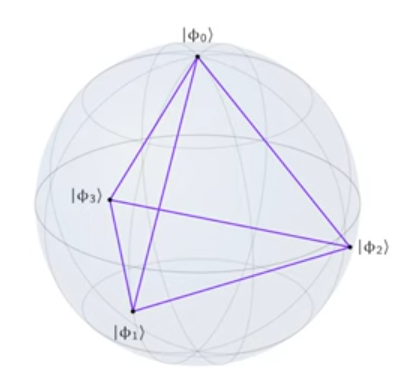

Each point is equidistant to each other.

We can define our measurement $\{P_0, P_1, P_2, P_3\}$ as follows.

$$ P_0 = \frac{\ket{\Phi_0}\bra{\Phi_0}}{2} \space P_1 = \frac{\ket{\Phi_1}\bra{\Phi_1}}{2} \space P_2 = \frac{\ket{\Phi_2}\bra{\Phi_2}}{2} \space P_3 = \frac{\ket{\Phi_3}\bra{\Phi_3}}{2}$$

These are the density matrix representation of the tetrahedral states divided by two.

Note that the measurements $\{P_0, P_1, P_2, P_3\}$ sums up to 1. If we average the 4 states, we get the completely mixed state, which is at the center of the Bloch Sphere. Since we divide each matrix by 2 rather than 4, we get twice the completely mixed state which is the identity.

Also these are not projective measurements.

## Measurements as channels

Recall that classical (probabilistic) states can be represented by diagonal density matrices. 

Because measurement outcomes are classical, we can think about measurements as being channels where the output is always a diagonal density matrix that describes the measurement outcome. 

Any general measurement can be described as a **channel $\Phi$**:
- The input system $X$ is the system being measured.
- The classical states of the output system $Y$ are the possible measurement outcomes $\{0,\dots,m-1\}$
- For every input state of $\rho$ of $X$, the output state $\Phi(\rho)$ is a diagonal density matrix.

### Example: standard basis measurement as channel

The *completely dephasing* channel $\Delta$ describes a standard basis measurement of a qubit:

$$ \Delta(\rho) = \bra{0}\rho\ket{0} \ket{0}\bra{0} +  \bra{1}\rho\ket{1} \ket{1}\bra{1} $$

In [6]:
import numpy as np

ket_plus = np.array([[1/np.sqrt(2)], [1/np.sqrt(2)]])
rho = ket_plus.dot(ket_plus.T)
print('input X')
print(rho)
print()

out = np.zeros(rho.shape)
for i in range(2):
    ket_i = np.array([[1] if j == i else [0] for j in range(2)])
    bra_i = ket_i.T
    res = bra_i.dot(rho.dot(ket_i)) * ket_i.dot(bra_i)
    out += res
    print(i)
    print(res)
    print()

print('out Y')
print(out)

input X
[[0.5 0.5]
 [0.5 0.5]]

0
[[0.5 0. ]
 [0.  0. ]]

1
[[0.  0. ]
 [0.  0.5]]

out Y
[[0.5 0. ]
 [0.  0.5]]


### Equivalence to matrix description

This is a **characterization** of general measurements. 

There are channels that don't represent measurements because the output might not always be a diagonal density matrix. But **if it is the case that the output of a channel is always a diagonal density matrix regardless of what input state $\rho$ we choose, then it is necessarily possible to express that channel in the form**:

$$ \Phi(\rho) = \sum_{a=0}^{m-1} \text{Tr}(P_a \rho) \ket{a}\bra{a} $$

for a measurement $\{P_0, \dots, P_{m-1}\}$.

Note that $\sum_i P_i = I$.

This basically tells us that our **definition of measurements as collections of matrices is NOT missing anything.** 
- another way of saying that, *this way of thinking about measurements as channels is operational* or axiomatic perhaps in a sense that it captures what a measurement should be, which is a phsyical process that transforms quantum information into classical information
- it turns out that it's completely equivalent to our first description of measurements which is purely algebraic

#### Channels to matrices

Suppose that we have a channel from $X$ to $Y$ with the property that 

$$ \Phi(\rho) = \Delta_m(\Phi(\rho)) $$

for every density matrix $\rho$.

- we assume this because $\Phi$ converts the input state $\rho$ to a classical (probabilistic) state

This may alternatively be expressed as follows.
$$ \Phi(\rho) = \sum_{a=0}^{m-1} \bra{a}\Phi(\rho)\ket{a} \space \ket{a}\bra{a} $$

Like all channels, we can express $\Phi$ in Kraus form for some way of choosing Kraus matrices $A_0, \dots, A_{N-1}$.

$$ \Phi(\rho)=\sum_{k=0}^{N-1}A_k\rho A_k^\dagger $$

This provides us with an alternative expression for the diagonal entries of $\Phi(\rho)$:

$$ \bra{a} \rho \ket{a} = \sum_{k=0}^{N-1}\bra{a}A_k\rho A_k^\dagger \ket{a}$$

- you can apply $\text{Tr}$ since the result is a scalar

$$ \text{Tr}(\bra{a} \rho \ket{a}) = \text{Tr}\left(\sum_{k=0}^{N-1}\bra{a}A_k\rho A_k^\dagger \ket{a}\right)$$

- left hand side is scalar so trace has no effect and for the right hand side, trace is linear so we can distribute

$$ \bra{a} \rho \ket{a} = \sum_{k=0}^{N-1}\text{Tr}\left(\bra{a}A_k\rho A_k^\dagger \ket{a}\right)$$

- use the cyclic property of trace

$$ \bra{a} \rho \ket{a} = \sum_{k=0}^{N-1}\text{Tr}\left(A_k^\dagger \ket{a}\bra{a}A_k\rho \right)$$

$$ \bra{a} \rho \ket{a} = \sum_{k=0}^{N-1}\text{Tr}\left(P_a\rho \right)$$

for $P_a = \sum_{k=0}^{N-1} A_k^\dagger \ket{a}\bra{a}A_k$

Thus, for these same matrices $P_0, \dots, P_{m-1}$ we can express the channel $\Phi$ as follows.

$$\Phi(\rho) = \text{Tr}(P_a\rho)\ket{a}\bra{a} $$

This expression is consistent with out description of general measurements in terms of matrices, as we see each measurement outcome appearing with probability $\text{Tr}(P_a\rho).$

Now let's observe that the two properties rquired of the collection of matrices $\{P_0, \dots, P_{m-1}\}$ to describe a general measurement are indeed satisfied. 

The **first property** is that they're all positive semidefinite matrices. One way to see this is to observe that, for every vector $\ket{\psi}$ having entries in correspondence with the classical state of $X$ we have

$$ \bra{\psi}P_a\ket{\psi} = \sum_{k=0}^{N-1} \bra{\psi} A_k^\dagger \ket{a}\bra{a} A_k \ket{\psi} = \sum_{k=0}^{N-1} |\bra{a}A_k\ket{\psi}|^2 \geq 0$$

Note that this is just another definition of positive semidefinite matrices, and norm square is always positive nonnegative value.

The **second property** is taht if we sum these matrices we get the identity matrix.

$$ \sum_{a=0}^{m-1}P_a = \sum_{a=0}^{m-1} \sum_{k=0}^{N-1} A_k^\dagger \ket{a}\bra{a}A_k $$

$$  =  \sum_{k=0}^{N-1} A_k^\dagger \sum_{a=0}^{m-1}(\ket{a}\bra{a}) A_k $$

- summing all $\ket{a}\bra{a}$s will result into identity

$$  =  \sum_{k=0}^{N-1} A_k^\dagger A_k $$

- since $\Phi$ is a channel, its Kraus matrices must satisfy the condition

$$  =  I_X $$


### Matrices to channels

Now let's verify that for any collection $\{P_0, \dots, P_{m-1}\}$ of positive semidefinite matrices satisfying $P_0+\dots+P_{m-1} = I_X$, the mapping defined by 

$$ \Phi(\rho) = \sum_{a=0}^{m-1} \text{Tr}(P_a\rho)\ket{a}\bra{a} $$

is indeed a valid channel from $X$ to $Y$.

One way to do this is to compute the Choi representation of this mapping.

$$ J(\Phi)=\sum_{b,c=0}^{n-1}\ket{b}\bra{c} \otimes \Phi(\ket{b}\bra{c}) $$
$$ =\sum_{b,c=0}^{n-1}\sum_{a=0}^{m-1}\ket{b}\bra{c} \otimes \text{Tr}(P_a\ket{b}\bra{c})\ket{a}\bra{a} $$

- use the cyclic property of trace

$$ =\sum_{b,c=0}^{n-1}\sum_{a=0}^{m-1}\ket{b}\bra{c} \otimes \text{Tr}(\bra{c}P_a\ket{b})\ket{a}\bra{a} $$

- trace applied to scalar can be simplified

$$ =\sum_{b,c=0}^{n-1}\sum_{a=0}^{m-1}\ket{b}\bra{c} \otimes \bra{c}P_a\ket{b}\ket{a}\bra{a} $$

- now we use the equality $\bra{c}P_a\ket{b} = \bra{b}P_a^T\ket{c}$

$$ =\sum_{b,c=0}^{n-1}\sum_{a=0}^{m-1}\ket{b}\bra{c} \otimes \bra{b}P_a^T\ket{c}\ket{a}\bra{a} $$

- move around the scalar value

$$ =\sum_{b,c=0}^{n-1}\sum_{a=0}^{m-1}\ket{b}\bra{b} P_a^T \ket{c}\bra{c} \otimes \ket{a}\bra{a}$$

$$ = \sum_{a=0}^{m-1} P_a^T \otimes \ket{a}\bra{a}$$

By the assumption that $P_0,\dots, P_{m-1}$ are positive semidefinite, so too are $P_0^T, \dots, P_{m-1}^T$. 

In particular, transposing a Hermitian matrix results in another Hermitian matrix, and the eigenvalues of any square matrix and its transpose always agree. 

If follows that $J(\Phi)$ is positive semidefinite. Tracing out the output system $Y$ (which is the system on the right - the $\ket{a}\bra{a}$) yields

$$ Tr_Y(J(\Phi)) =  \sum_{a=0}^{m-1} P_a^T = I_X^T = I_X$$

***Note: In Lesson 10, the normalized Choi representation (the Choi state) was used, so tracing out the output system Y yields the completely mixed state $\frac{I_X}{n}$. Here we are using the unnormalized Choi representation, so tracing out $Y$ yields $I_X$ instead.***

# Partial measurements

Meaning one part of a compound system is being measured.

Suppose that a pair of systems $(X,Z)$ is in a state $\rho$ and a measurement $\{P_0, \dots, P_{m-1}\}$ is performed on $X$. 

This results in a measurement outcome -- and in addition the state of $Z$ may change depending on the outcome. 

## Outcome probabilities

Because we are talking about a measurement on system $X$ alone, the probabilities of different outcomes to appear can only depend on the state of $X$ in isolation. Which is to say, they can only depend on **reduced state of $X$**. 

*The probabilities for different measurement outcome probabilities to appear depend only on the measurement and the reduced state $\rho_X$ of $X$.*

$$\text{Prob}(\text{outcome} = a) = \text{Tr}(P_a\rho_X)$$

- we obtain the $\rho_X$ by tracing $Z$

$$\text{Tr}(P_a\rho_X) = \text{Tr}(P_a \text{Tr}_Z(\rho))$$

We can also obtain this equality

$$\text{Tr}(P_a \text{Tr}_Z(\rho)) = \text{Tr}((P_a\otimes I_Z)\rho)$$

- To prove this equality, let $\rho=M\otimes N$. *You cannot express all density matrices in this form. This is to simplify first.*

$$\text{Tr}(P_a \text{Tr}_N(M\otimes N)) = \text{Tr}((P_a\otimes I_N)(M\otimes N))$$

- Use the trace property $\text{Tr}(M\otimes N) = \text{Tr}(N)M$

$$\text{Tr}(P_a \text{Tr}(N)M) = \text{Tr}((P_a\otimes I_N)(M\otimes N))$$

- Since $\text{Tr}(N)$ is a scalar, we can move it around

$$\text{Tr}(N)\text{Tr}(P_a M) = \text{Tr}((P_a\otimes I_N)(M\otimes N))$$

- For the right hand side, we use the property $(A\otimes B)(C\otimes D) = AC \otimes BD$

$$\text{Tr}(N)\text{Tr}(P_a M) = \text{Tr}(P_a M\otimes N)$$

- We use the property of trace $\text{Tr}(A\otimes B) = \text{Tr}(A)\text{Tr}(B)$

$$\text{Tr}(N)\text{Tr}(P_a M) = \text{Tr}(P_a M)\text{Tr}(N)$$

$$\text{Tr}(N)\text{Tr}(P_a M) = \text{Tr}(N)\text{Tr}(P_a M)$$

Note that for every density matrix $\rho$, **we can always express $\rho=\sum_i M_i \otimes N_i$** where $M_i$ and $N_i$ are arbtrary matrices with appropriate sizes. And since trace is a linear function it works for all $\rho$.

## States conditioned on measurement outcomes

To determine the state of $Z$ conditioned on a given measurement outcome we can turn to the **channel description of the measurement**:

$$ \Phi(\sigma) = \sum_{a=0}^{m-1} \text{Tr}(P_a\sigma) \ket{a}\bra{a} $$

***In this formula, $\sigma$ represents a state of the system $X$ alone.***

In particular, let's examine the state we get when we apply $\Phi$ to $X$ and do nothing to $Z$. Since we can express $\rho = \sum_{b,c=0}^{n-1} \ket{b}\bra{c}\otimes \rho_{b,c}$, we get

$$(\Phi \otimes \text{Id}_Z)(\rho) = \sum_{b,c=0}^{n-1} \Phi(\ket{b}\bra{c})\otimes \rho_{b,c}$$

- now we apply the channel $\Phi$

$$(\Phi \otimes \text{Id}_Z)(\rho) = \sum_{b,c=0}^{n-1}\sum_{a=0}^{m-1} \text{Tr}(P_a\ket{b}\bra{c}) \ket{a}\bra{a}\otimes \rho_{b,c}$$

- separate $\ket{a}\bra{a}$

$$  = \sum_{a=0}^{m-1}\ket{a}\bra{a}\otimes \sum_{b,c=0}^{n-1} \text{Tr}(P_a\ket{b}\bra{c}) \rho_{b,c}$$

- we use the equality, $ \text{Tr}(P_a\ket{b}\bra{c}) \rho_{b,c} = \text{Tr}_X((P_a\otimes I_Z)\rho)$
  - if we assume $X=P_a\ket{b}\bra{c}$ and $Z=\rho_{b,c}$ and use the property $\text{Tr}(X)Z = \text{Tr}_X(X\otimes Z)$
  - we get, $\text{Tr}(P_a\ket{b}\bra{c})\rho_{b,c} = \text{Tr}_X((P_a \otimes I_Z) (\ket{b}\bra{c} \otimes \rho_{b,c}))$
  - remember that $\rho=\ket{b}\bra{c} \otimes \rho_{b,c}$
  - so we get $\text{Tr}_X((P_a \otimes I_Z) (\ket{b}\bra{c} \otimes \rho_{b,c})) = \text{Tr}_X((P_a \otimes I_Z)\rho)$

$$  = \sum_{a=0}^{m-1}\ket{a}\bra{a}\otimes \text{Tr}_X((P_a\otimes I_Z)\rho)$$

One final step transforms this expression into one that reveals what we're looking for.

Multiply $ \frac{\text{Tr}((P_a\otimes I_Z)\rho)}{\text{Tr}((P_a\otimes I_Z)\rho)} $ to the last expression. We get

$$  = \frac{\text{Tr}((P_a\otimes I_Z)\rho)}{\text{Tr}((P_a\otimes I_Z)\rho)}\sum_{a=0}^{m-1}\ket{a}\bra{a}\otimes \text{Tr}_X((P_a\otimes I_Z)\rho)$$

Move around the numerator and denominator.

$$  = \sum_{a=0}^{m-1}\text{Tr}((P_a\otimes I_Z)\rho)\ket{a}\bra{a}\otimes \frac{\text{Tr}_X((P_a\otimes I_Z)\rho)}{\text{Tr}((P_a\otimes I_Z)\rho)}$$

This is an example of a *classical-quantum state*, 

$$ \sum_{a=0}^{m-1}p(a)\ket{a}\bra{a}\otimes \sigma_a$$,

like we saw in lesson 9. For each measurement outcome $a\in\{0,\dots, m-1\}$, we have with probability

$$ p(a) = \text{Tr}((P_a\otimes I_z)\rho) $$

that $Y$ is in the classical state $\ket{a}\bra{a}$ and $Z$ is in the state

$$ \sigma_a = \frac{\text{Tr}_X((P_a\otimes I_Z)\rho)}{\text{Tr}((P_a\otimes I_Z)\rho)} $$

That is, this is the density matrix we obtain by normalizing 

$$ \text{Tr}_X((P_a\otimes I_Z)\rho)$$

by dividing it by its trace. (Formally speaking, the state $\sigma_a$ is only defined when the probability $p(a)$ is nonzero; when $p(a)=0$ this state is irrelevant, for it refers to a discrete event that occurs with probability zero.)

- this means that if the state $a$ of $X$ has probability $p(a) =  \text{Tr}((P_a\otimes I_Z)\rho)= 0$, which will make a division error (division by 0), 
- then the condition probability $$ \sigma_a = \frac{\text{Tr}_X((P_a\otimes I_Z)\rho)}{\text{Tr}((P_a\otimes I_Z)\rho)} $$ is undefined, because that condition will not happen.

## Summary
When a measurement $\{P_0, \dots, P_{m-1}\}$ is performed on $X$ when $(X,Z)$ is in the state $\rho$, the following happens:

1. Each outcome $a$ appears with probability $\text{Tr}((P_a\otimes I_Z)\rho)$
2. Conditioned on obtaining the outcome $a$, the state of $Z$ becomes

$$ \frac{\text{Tr}_X((P_a\otimes I_Z)\rho)}{\text{Tr}((P_a\otimes I_Z)\rho)} $$

# Naimark's Theorem

Naimark's theorem is a fundamental fact concerning measurements. It states that every general measurement can be implemented in the following way:

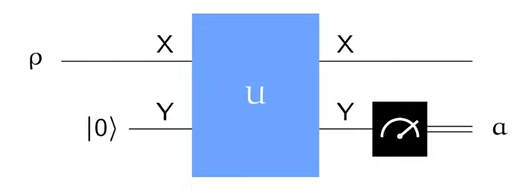

In words...

That is, a given general measurement $\{P_0, \dots, P_{m-1}\}$ on $X$ can be implemented as follows.

1. Introduce an initialized workspace system $Y$ having classical states $\{0,\dots, m-1\}$.
2. Perform a unitary operation $U$ on the pair $(Y,X)$.
3. Perform a standard basis measurement on $Y$.

## Proof of Naimark's Thorem

Not difficult to prove... just need to make a good choice for $U$ and verify that it works.

***FACT FROM MATRIX THOERY***

For every positive semidefinite matrix $P$, there is a unique positive semidefinite matrix $Q$ such that $Q^2 = P$. This is matrix is denoted $\sqrt{P}$.

- In general, there could be many matrices that can get us $P$ by squaring, but there is **always one matrix that's positive semidefinite**

We can calculate $\sqrt{P}$ using spectral decomposition of $P$:

$$ P=\sum_{k=0}^{n-1} \lambda_k \ket{\psi_k}\bra{\psi_k} \Rightarrow \sqrt{P}=\sum_{k=0}\sqrt{\lambda_k} \ket{\psi_k}\bra{\psi_k} $$

---

We will use this fact to construct $U$.

Any unitary matrix $U$ that follows this pattern will work:

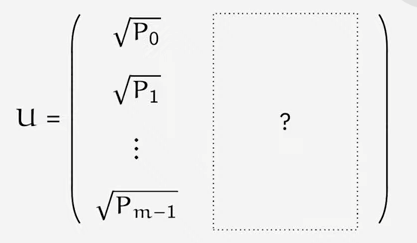

The first $n$ columns, assuming $X$ has $n$ classical states like before, are obtained by stacking the square roots of the matrices that describe the measurement on top of one another. The remaining columns are whatever we want, it doesn't make any difference, as long as the entire matrix is unitary.

*Note: this is similar concept from lesson 10 where the equivalence between the Kraus to Stringspring representations is proven. This is essentially a special case of that, where ALL KRAUS MATRICES ARE POSITIVE SEMIDEFINITE.*

We need to check two things:
1. such a matrix $U$ works correctly
2. that $U$ can be made unitary

**Proof for #1**
- starting with the initial state

$$ \ket{0}\bra{0}\otimes \rho $$

- we perform $U$, means we conjugate by $U$

$$ U(\ket{0}\bra{0}\otimes \rho)U^\dagger $$

- visualizing this in block matrices, we get

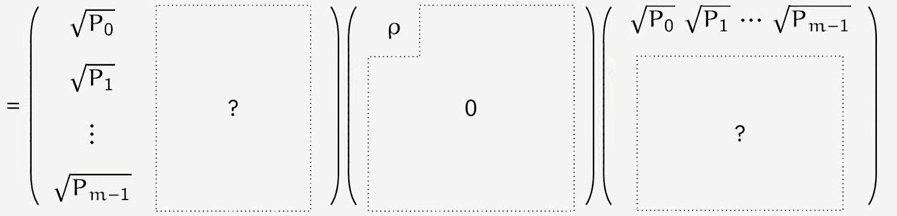

- we can see that the other parts of $U$ is not necessary as it is getting multiplied to 0 from the matrix in the middle
- if we evaluate the multiplication, we get

$$ U(\ket{0}\bra{0}\otimes \rho)U^\dagger = \begin{pmatrix}
    \sqrt{P_0}\rho\sqrt{P_0} & \dots & \sqrt{P_0}\rho\sqrt{P_{m-1}} \\
    \vdots & \ddots & \vdots \\
    \sqrt{P_{m-1}}\rho\sqrt{P_0} & \dots & \sqrt{P_{m-1}}\rho\sqrt{P_{m-1}}
\end{pmatrix} $$

- alternatively, we can express it as a dirac notation

$$= \sum_{a,b=0}^{m-1} \ket{a}\bra{b}\otimes \sqrt{P_a}\rho\sqrt{P_b} $$

- let's assign this expression to $\sigma$ for convenience

$$ \sigma = \sum_{a,b=0}^{m-1} \ket{a}\bra{b}\otimes \sqrt{P_a}\rho\sqrt{P_b} $$

- now the last step is to measure the system $Y$, using the property $\text{Tr}_B(A\otimes B) = \text{Tr}(B)A$

$$ \sigma_Y = \sum_{a,b=0}^{m-1} \text{Tr}\left(\sqrt{P_a}\rho\sqrt{P_b}\right) \ket{a}\bra{b} $$

- so if we get the probability of getting state $a$, we get the expression

$$ \text{Prob}(\text{outcome}=a)=\bra{a}\sigma_Y\ket{a} = \bra{a}\left(\sum_{a,b=0}^{m-1} \text{Tr}\left(\sqrt{P_a}\rho\sqrt{P_b}\right) \ket{a}\bra{b}\right)\ket{a} = \sum_{a,b=0}^{m-1} \text{Tr}\left(\sqrt{P_a}\rho\sqrt{P_b}\right) \bra{a}\ket{a}\bra{b}\ket{a} $$

- if $a\neq b$, it will be 0, otherwise, we get

$$ = \text{Tr}\left(\sqrt{P_a}\rho\sqrt{P_a}\right) $$

- using the cyclic property of trace

$$ \text{Tr}\left(\sqrt{P_a}\rho\sqrt{P_a}\right) = \text{Tr}\left(\sqrt{P_a}\sqrt{P_a}\rho\right) = \text{Tr}\left(P_a \rho\right)$$

- this is the result what we are hoping for
- so the probabilities for different outcomes to appear are correct
- they always agree with the original measurement that we started with

**Proof for #2**

- it's both necessary and sufficient that the first $n$ columns, which are formed by the blocks $\sqrt{P_0},\dots,\sqrt{P_{m-1}}$, are orthonormal.
- we can use the **Gram-Schmidt orthogonalization process to fill in the remaining columns**
- the first $n$ columns of $U$ can be expressed as vectors in the followsing way, where $c=0,\dots,n-1$ refers to the column number starting from 0

$$\ket{\gamma_c} = \sum_{a=0}^{m-1}\ket{a}\otimes \sqrt{P_a}\ket{c} $$

- we can compute the inner product between any two of them as folows.

$$ \braket{\gamma_c|\gamma_d} = \sum_{a,b=0}^{m-1}\braket{a|b} \cdot\bra{c}\sqrt{P_a}\sqrt{P_b}\ket{d} = \bra{c}\left(\sum_{a=0}^{m-1}P_a\right)\ket{d} = \braket{c | d} $$

this shows that these columns are in fact orthonormal, so we can fill in the remaining columns of $U$ in a way that guarantees the entire matrix is unitary. **Using the Gram-Schmidt process** (not discussed here).

In [75]:
# example tetrahedral states

import numpy as np
from math import e

phi_0 = np.array([[1],[0]])
phi_1 = np.array([[1/np.sqrt(3)],[np.sqrt(2/3)]])
phi_2 = np.array([[1/np.sqrt(3)],[np.sqrt(2/3)*e**(2*1j*np.pi/3)]])
phi_3 = np.array([[1/np.sqrt(3)],[np.sqrt(2/3)*e**(-2*1j*np.pi/3)]])

P_0 = phi_0.dot(phi_0.T.conj()) / 2
P_1 = phi_1.dot(phi_1.T.conj()) / 2
P_2 = phi_2.dot(phi_2.T.conj()) / 2
P_3 = phi_3.dot(phi_3.T.conj()) / 2
print('P_0')
print(P_0)
print()
print('P_1')
print(P_1)
print()
print('P_2')
print(P_2)
print()
print('P_3')
print(P_3)
print()
print('Condition: all P summed to I')
print(np.round(P_0 + P_1 + P_2 + P_3, 10))
print()

# function to get the sqrt(P)
def get_sqrt(P):
    sqrt_P = np.zeros(P.shape).astype(complex)
    eig_vals, eig_vecs = np.linalg.eig(P)
    for i in range(eiv_vecs.shape[1]):
        eig_val = eig_vals[i]
        eig_vec = eig_vecs[:,i:i+1]
        sqrt_P += np.sqrt(eig_val) * eig_vec.dot(eig_vec.T.conj())

    return sqrt_P

sqrt_P_0 = get_sqrt(P_0)
print('sqrt_P_0')
print(sqrt_P_0)
print()
sqrt_P_1 = get_sqrt(P_1)
print('sqrt_P_1')
print(sqrt_P_1)
print()
sqrt_P_2 = get_sqrt(P_2)
print('sqrt_P_2')
print(sqrt_P_2)
print()
sqrt_P_3 = get_sqrt(P_3)
print('sqrt_P_3')
print(sqrt_P_3)
print()

list_res = [sqrt_P_0,sqrt_P_1,sqrt_P_2,sqrt_P_3]
for i, sqrt_P in enumerate(list_res):
    print(f'sqrt_P_{i} is positive semidefinite: {(np.linalg.eigvals(sqrt_P) >= 0).all()}')
print()

stacked_sqrt_P = np.vstack(list_res)
print('stacked_sqrt_P')
print(stacked_sqrt_P)
print()

print("GAMMA_C Representation of stacked_sqrt_P")
m = 4 # number of measurements
n = 2 # first n columns that contains the columns of stacked_sqrt_P
def get_gamma_c(m, n, c, list_res):
    gamma_c = np.zeros((m*n,1)).astype(complex)
    for a in range(m):
        ket_a = np.array([[1] if i == a else [0] for i in range(m)])
        ket_c = np.array([[1] if i == c else [0] for i in range(n)])
        sqrt_P_a = list_res[a]
        gamma_c += (np.kron(ket_a, sqrt_P_a.dot(ket_c)))
    return gamma_c

print()
gamma_0 = get_gamma_c(m=m, n=n, c=0, list_res=list_res)
print("gamma_0")
print(gamma_0)


print()
gamma_1 = get_gamma_c(m=m, n=n, c=1, list_res=list_res)
print("gamma_1")
print(gamma_1)

print()
print("gamma_0_dagger DOT gamma_0")
print(np.round(gamma_0.T.conj().dot(gamma_0), 10))

print()
print("gamma_0_dagger DOT gamma_1")
print(np.round(gamma_0.T.conj().dot(gamma_1), 10))

print()
print("gamma_1_dagger DOT gamma_0")
print(np.round(gamma_1.T.conj().dot(gamma_0), 10))

print()
print("gamma_1_dagger DOT gamma_1")
print(np.round(gamma_1.T.conj().dot(gamma_1), 10))

P_0
[[0.5 0. ]
 [0.  0. ]]

P_1
[[0.16666667 0.23570226]
 [0.23570226 0.33333333]]

P_2
[[ 0.16666667+0.j         -0.11785113-0.20412415j]
 [-0.11785113+0.20412415j  0.33333333+0.j        ]]

P_3
[[ 0.16666667+0.j         -0.11785113+0.20412415j]
 [-0.11785113-0.20412415j  0.33333333+0.j        ]]

Condition: all P summed to I
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

sqrt_P_0
[[0.70710678+0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j]]

sqrt_P_1
[[0.23570226+0.j 0.33333333+0.j]
 [0.33333333+0.j 0.47140452+0.j]]

sqrt_P_2
[[ 0.23570226+2.85627860e-09j -0.16666667-2.88675133e-01j]
 [-0.16666666+2.88675135e-01j  0.47140452+1.42813930e-09j]]

sqrt_P_3
[[ 0.23570226-2.85627860e-09j -0.16666667+2.88675133e-01j]
 [-0.16666666-2.88675135e-01j  0.47140452-1.42813930e-09j]]

sqrt_P_0 is positive semidefinite: True
sqrt_P_1 is positive semidefinite: True
sqrt_P_2 is positive semidefinite: True
sqrt_P_3 is positive semidefinite: True

stacked_sqrt_P
[[ 0.70710678+0.00000000e+00j  0.        +0.000

# Non-destructive measurements

So far in the lesson, we've kept our focus on destructive measurements. Meaning that there's *no specification of the post-measurement quantum state of the system that was measured.* 

**Non-destructive measurements**, on the other hand, have not only a classical measurement outcome, but also a ***post-measurement quantum state of the system that was measured.***

*Note: there is a natural connection to Naimark's theorem.*

There are different specific ways to formulate non-destructive measurements in mathematical terms but we'll start with **one formulation that comes directly from Naimark's theorem.** 

## Non-destructive measurements from Naimark's theorem

Consider a general (destructive) measurement $\{P_0,\dots,P_{m-1}\}$ of a system $X$.

We can define a *non-destructive* measurement with the same outcome probabilities using Naimark's theorem,

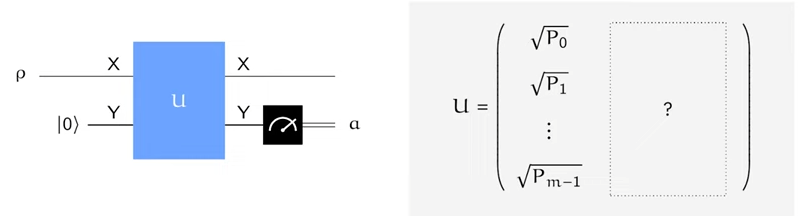

Conditioned on the outcome $a$ the state of $X$ becomes this:

$$ \frac{\sqrt{P_a}\rho\sqrt{P_a}}{\text{Tr}(P_a\rho)} $$

- we conjugate by the $\sqrt{P_a}$, and then normalize

## Non-destructive measurements from Kraus matrices (more general)

There are *alternative selections* for $U$ in the context of Naimark's theorem that produce the same measurement outcome probbailities but give entirely different output states of $X$.

For instance, one option is to substitute $(I_Y\otimes V)U$ for $U$, where $V$ is any unitary operation on $X$. 

$$ U(\ket{0}\bra{0}\otimes\rho)U^\dagger = ((I_Y\otimes V)U)(\ket{0}\bra{0}\otimes\rho)((I_Y\otimes V)U)^\dagger $$

$$  = ((I_Y\otimes V)U)(\ket{0}\bra{0}\otimes\rho)(U^\dagger(I_Y\otimes V)^\dagger) $$

$$  = ((I_Y\otimes V)U)(\ket{0}\bra{0}\otimes\rho)(U^\dagger(I_Y^\dagger\otimes V^\dagger)) $$

$$  = ((I_Y\otimes V)U)(\ket{0}\bra{0}\otimes\rho)(U^\dagger(I_Y\otimes V^\dagger)) $$

$$  = (I_Y\otimes V)(U(\ket{0}\bra{0}\otimes\rho)U^\dagger)(I_Y\otimes V^\dagger) $$

- we know that $U(\ket{0}\bra{0}\otimes\rho)U^\dagger = \sum_{a,b=0}^{m-1} \ket{a}\bra{b}\otimes \sqrt{P_a}\rho\sqrt{P_b} $, and we use this equality

$$  = (I_Y\otimes V)\left(\sum_{a,b=0}^{m-1} \ket{a}\bra{b}\otimes \sqrt{P_a}\rho\sqrt{P_b}\right)(I_Y\otimes V^\dagger) $$

$$  = \sum_{a,b=0}^{m-1} \ket{a}\bra{b}\otimes V\sqrt{P_a}\rho\sqrt{P_b}V^\dagger $$

- this is our $\sigma$ now

$$ \sigma  = \sum_{a,b=0}^{m-1} \ket{a}\bra{b}\otimes V\sqrt{P_a}\rho\sqrt{P_b}V^\dagger $$

- isolating $Y$ will give us

$$ \sigma_Y  = \text{Tr}_X\left(\sum_{a,b=0}^{m-1} \ket{a}\bra{b}\otimes V\sqrt{P_a}\rho\sqrt{P_b}V^\dagger\right) $$

$$ = \sum_{a,b=0}^{m-1} \text{Tr}\left(V\sqrt{P_a}\rho\sqrt{P_b}V^\dagger\right) \ket{a}\bra{b}  $$

- getting the probability

$$ \bra{a}\sigma_Y\ket{a} = \bra{a}\left(\sum_{a,b=0}^{m-1} \text{Tr}\left(V\sqrt{P_a}\rho\sqrt{P_b}V^\dagger\right) \ket{a}\bra{b}\right)\ket{a} $$

$$ = \sum_{a,b=0}^{m-1} \text{Tr}\left(V\sqrt{P_a}\rho\sqrt{P_b}V^\dagger\right) \bra{a}\ket{a}\bra{b}\ket{a} $$

$$ = \text{Tr}\left(V\sqrt{P_a}\rho\sqrt{P_b}V^\dagger\right) $$

$$ = \text{Tr}\left(\sqrt{P_b}V^\dagger V\sqrt{P_a}\rho\right) $$

- since $V$ is unitary, $V^\dagger V = I$, and we get

$$ = \text{Tr}\left(\sqrt{P_b}\sqrt{P_a}\rho\right) $$

$$ = \text{Tr}\left(P_b\rho\right) $$

We observed that the application $V$ to $X$ commutes with the measurement of $Y$ so the **classical outcome probabilities do not change**, but now the state of $X$ conditioned on the outcome $a$ becomes

$$ \frac{V\sqrt{P_a}\rho\sqrt{P_a}V^\dagger}{\text{Tr}(P_a\rho)} $$

More generally, we could replace $U$ by the unitary matrix 

$$\left(\sum_{a=0}^{m-1}\ket{a}\bra{a}\otimes V_a \right) U $$

for any choice of unitary operations $V_0,\dots,V_{m-1}$ on $X$. Again, the classical outcome probabilities are unchanged, but now the state of $X$ conditioned on the outcome $a$ becomes

$$\frac{V_a \sqrt{P_a}\rho\sqrt{P_a} V_a^\dagger}{\text{Tr}(P_a\rho)} $$

An equivalent way to express this freedom is connected with Kraus representations. That is, we can describe an $m$-outcome non-destructive measurement of a system having $n$ classical states by a selection $n\times n$ Kraus matrices $A_0,\dots,A_{m-1}$ satisfying the typical condition for Kraus matrices.

$$ \sum_{a=0}^{m-1} A_a^\dagger A_a = I_X $$

Assuming that the initial state of $X$ is $\rho$, the classical measurement outcome is $a$ with probability

$$ \text{Tr}(A_a\rho A_a^\dagger) = \text{Tr}(A_a^\dagger A_a \rho) $$

and conditioned upon the outcome being state $a$ the state of $X$ becomes 

$$ \frac{A_a\rho A_a}{\text{Tr}(A_a^\dagger A_a \rho)} $$

Note that this is equivalent to choosing the unitary operation $U$ in Naimark's theorem as follows.

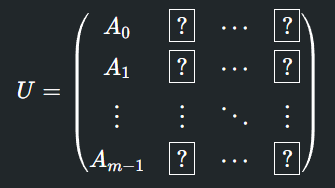

In lesson 10, we observed that the columns formed by the blocks $A_0,\dots,A_{m-1}$ are necessarily orthogonal, by virtue of the condition required by Kraus matrices.

## Generalizations

There are even more general ways to formulate non-destructive measurements thatn the ways we've discussed. The notion of a *quantum instrument* (which won't be described here) represents one way to do this.

# State Discrimination and Tomography

These are *two tasks* associated with measurements. 

## Quantum State Discrimination

Let $\rho_0,\dots, \rho_{m-1}$ be quantum states of a system $X$ and let $(p_0, \dots, p_{m-1})$ be a probability vector.

- let's assume that $\rho_0,\dots, \rho_{m-1}$ are density matrices representing possible quantum states of a system $X$ and $(p_0, \dots, p_{m-1})$ are the probabilities associated with these states
- a succint way of saying this is we have an **ensemble of quantum states**

An abstract way that we can think about quantum state discrimination *as a task or as a problem* is that:
- An element $a\in\{0,\dots,m-1\}$ is chosen ar random according to the probabilities $(p_0, \dots, p_{m-1})$
- The system $X$ is prepared in the state $\rho_a$ (state corresponding to the randomly selected number $a$)
- **Goal: determine $a$ by measuring $X$**
  - determine which number is chosen (which $a$)
 
So, we have a finite number of alternatives along with a prior and the goal is to determine which alternative actually happened. For some choices of states and probabilities, this may be easy and for others, it may not be possible to do this **without some chance of making an error.**

There are various questions that we could ask such as what is the *minimum probability of making an error and what does a measurement that achieves this minimum probability of error look like*. 

## Quantum State Tomography

Let $\rho$ be an unknown quantum states of a system.

- Identical systems $X_1,\dots,X_N$ are each independently prepared in state $\rho$.
  - this time, it's not a single copy of the state that's made available but rather any independent copies are made available
  - which is to say that for some possible large number $n$ we have $n$ identical systems $X_1, \dots, X_N$ that are each independently prepared i the state $\rho$
- **Goal approximate $\rho$ by measuring $X_1, \dots, X_N$**

***SUMMARY***

**State discrimination** - we have a single copy of the state and we're trying to discriminate among a finite number of known alternatives 

**State tomography** - we have many independent copies of an uknown copies of an unknown quantum state and the goal is to find a description or at least decent approximation